# Linear Regression Assumptions: Linearity

This notebook focuses on the "linearity" assumption of linear regression. But first, we'll recap linear regression basics and go through all of the assumptions of linear regression.

Linear regression is a predictive model that models the relationship between input (X) and output (Y) variables.

For every datapoint $n$, the model assumes:

yₙ = β₀ + β₁xₙ + εₙ

Where:
- β₀ = intercept
- β₁ = slope
- εₙ = error term

Linear regression models the **mean (average)** of Y given X. So $y_n$ is actually the estimate of the mean value of Y given specific values of the $\beta$ coefficients and the input $x$.

# Assumptions of Linear Regression
You can think of predictive models as simplifying lenses for understanding phenomena. They aren't perfect, but they can still be useful to make predictions and to understand the relationships among variables.

It's important to understand what simplifying assumptions models make so you can choose between them and understand their limitations. We'll go through the assumptions of linear regression here.

## 1. Linearity of the Mean

The mean of the output (denoted here as $\mu_n$ as an alternative to $y_n$) is a linear combination of predictors.

μₙ = β₀ + β₁xₙ

This means that while individual data points may be scattered due to noise, the average relationship between input and output follows a straight line. Linear regression is therefore modeling the average, sometimes called *expected value* of the response, not each individual observation.  

**However,** even if the data looks curved, we can often transform inputs (like x², log(x), sin(x)) to still use a linear model.



## 2. Normality of Errors

Errors are normally distributed:

εₙ ~ Normal(0, σ)

This means that for any given input value, the observed outputs are distributed like a normal (Gaussian) distribution. Most values lie close to the "peak" of the normal distribution at its mean, with fewer extreme deviations.  The regression line is that mean prediction across input values, so we should expect most datapoints to fall along that regression line.


## 3. Independence

Linear regression also assumes that datapoints are independent of each other. The errors in predicting the outputs are not correlated with each other.

Independence means that one observation does not influence another, and the error in one prediction gives no information about another.

We won't go into this assumption much, but it's good to be aware of it for when to choose linear regression.

In time-series data, independence is violated because **current values depend on past values**, creating patterns or correlations between errors.


## 4. Constant Variance (Homoscedasticity)

Variance of the output Y is constant across all inputs.

This means that the spread of data points around the regression line is **uniform across all values of x**, forming an even “band” around the line. The uncertainty in predictions should not increase or decrease with the input.  

We also won't go into this assumption much, but it's something to be aware of.

# What Does "Linear" Mean?

Let's dig into that first assumption about linearity of the relationship between the input and the mean output. Linear regression is part of a family of statistical models called "linear" models. So what does linear mean? We often think of it as a straight, best fit line between input and output. But that's not actually the case!

"Linear" means the mean output is linearly related to the regression coefficients ($\beta$), not the input data itself. **You can transform the input in whatever way you want first and as long as the coefficient is outside that transformation, it's still a linear model.**

For example,

y = β₀ + β₁ sin(x)

is STILL a linear model because β is outside the transformation of x into sin(x).

We can transform inputs and still use linear regression.

Let's demonstrate this in code.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

First we'll generate some data that clearly has a linear relationship between input and output without any transformation needed. We'll generate some random noise (errors) from a normal distribution since that fits linear regression's assumptions. This model will have a slope of 1 and intercept of 1.

In [2]:
np.random.seed(42)

data = pd.DataFrame({'x': np.linspace(-2, 2, 50)})
noise = np.random.normal(0, 0.5, size=len(data))
data['y'] = 1 + data['x'] + noise
data.info()
data.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   x       50 non-null     float64
 1   y       50 non-null     float64
dtypes: float64(2)
memory usage: 932.0 bytes


,x,y
0,-2.000000,-0.751643
1,-1.918367,-0.987499
2,-1.836735,-0.512890
3,-1.755102,0.006413
4,-1.673469,-0.790546


If we plot a scatterplot of the data, it clearly has a linear relationship. Let's plot the data with the noise compared to a "best fit line" that corresponds to a linear regression model with an intercept ($\beta_0$) of 1 and slope ($\beta_1$) of 1, i.e.:
$$ y = 1 + x $$
This is the same relationship that we generated the data from, so I bet it will match well 😆.

First we'll add a column of data that captures this linear regression model's exact predictions. This will form a straight line.

In [3]:
data['estimated_y'] = 1 + data['x']
data.head()

,x,y,estimated_y
0,-2.000000,-0.751643,-1.000000
1,-1.918367,-0.987499,-0.918367
2,-1.836735,-0.512890,-0.836735
3,-1.755102,0.006413,-0.755102
4,-1.673469,-0.790546,-0.673469


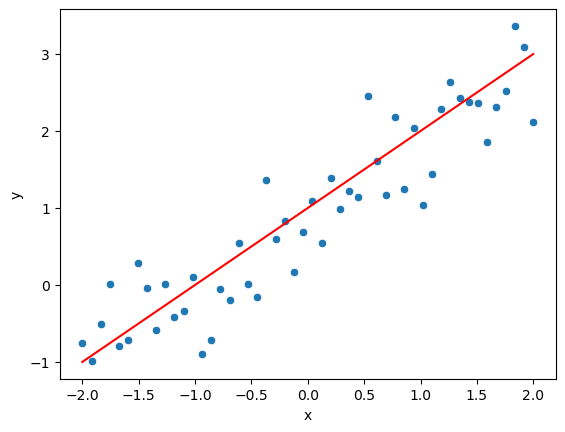

In [4]:
fig, ax = plt.subplots()
sns.scatterplot(data=data, x='x', y='y', ax=ax)
sns.lineplot(data=data, x='x', y='estimated_y', ax=ax, color='red')
plt.show()

## Feature Transformation (Non-Linear Data → Linear Model)

Now let's generate some data that clearly does **not** have a linear relationship between the input and output. But we can still use a linear model like linear regression! To do so, we will first transform the data with a nonlinear transformation. After it's been transformed (a process sometimes called "feature transformation"), linear regression can be used to model a linear relationship between the transformed "features" and the output.

For example:
y = β₀ + β₁ sin(x)

is STILL linear in β.

Let's take a look at this in code. First we'll generate some data with a nonlinear (sine-wave) pattern.

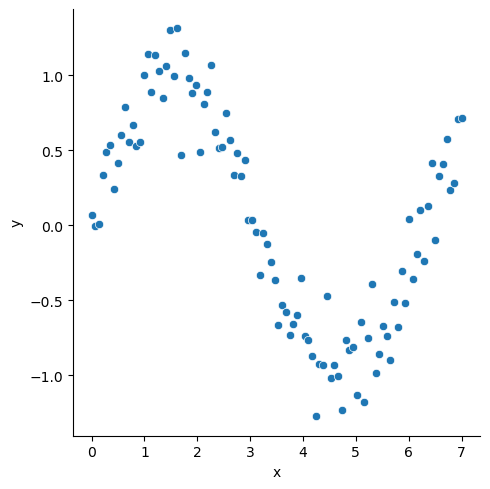

In [5]:
data = pd.DataFrame({'x': np.linspace(0, 7, 100)})
noise = np.random.normal(0, 0.2, size=len(data))
data['y'] = np.sin(data['x']) + noise

sns.relplot(data=data, x='x', y='y')
plt.show()

If you saw this kind of a relationship in exploratory data analysis, you might think that you can't use linear regression since the relationship looks so nonlinear. If you trained a linear regression model to directly model the relationship between `x` and `y`, there wouldn't be a straight best fit line that matches the data well.

But you actually can still use a linear model! The key is to **transform the input `x` with a nonlinear function first**, and then model a linear relationship with that transformed feature.

How do you know which feature transformation might work? It's useful to be aware of the general shape of a few nonlinear transformations of data. This notebook will illustrate a couple of them: the cyclical sine wave shape and polynomial shapes.

Let's first do that nonlinear feature transformation and see how that changes the relationship to the output `y`.

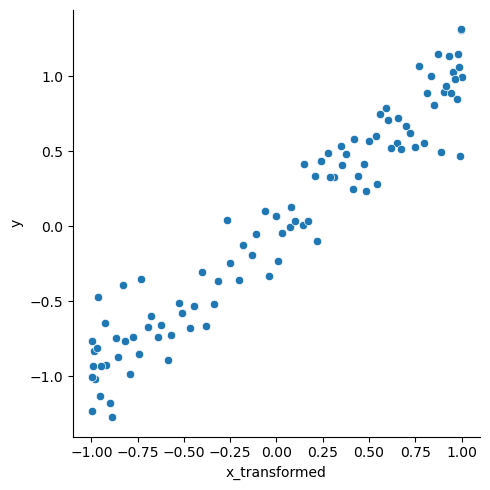

In [6]:
# Transform feature
data['x_transformed'] = np.sin(data['x'])

sns.relplot(data=data, x='x_transformed', y='y')
plt.show()

Now the linear relationship between the transformed feature (sine of `x`) is clear!

# Polynomial Regression

Another nonlinear transformation to be aware of is a polynomial transformation. Here the relationship involves taking the input $x$ to some numerical power. For example:

$$ y = \beta_0 + \beta_1 x^2 $$

At first glance, this looks like a **non-linear model**, because the relationship between x and y is curved. Let's generate some data that has this kind of relationship and take a look. Specifically, we'll generate data that roughly matches a model with $\beta_0$ (intercept) of 0 and $\beta_1$ of 3. 

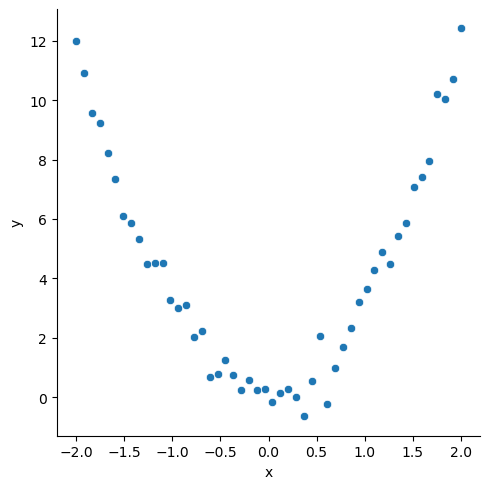

In [7]:
np.random.seed(9)

data = pd.DataFrame({'x': np.linspace(-2, 2, 50)})
noise = np.random.normal(0, 0.5, size=len(data))
data['y'] = 3*np.power(data['x'], 2) + noise

sns.relplot(data=data, x='x', y='y')
plt.show()

Once again, we can see that this data does not appear to have a linear relationship between `x` and `y`. It has a rough parabola shape instead.

Can we still handle it with linear regression? Yes, by transforming the input first!

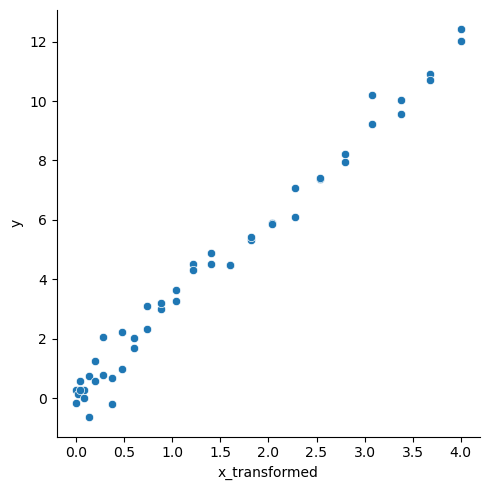

In [8]:
# Transform feature
data['x_transformed'] = np.power(data['x'], 2)

sns.relplot(data=data, x='x_transformed', y='y')
plt.show()

In this case, the new "feature" (input variable for a regression model) is $x^2$. A coefficient can be learned for that transformed feature just like any other variable. So if we assign $f = x^2$, we could rewrite our linear regression equation for this model as:
$$ y = \beta_0 + \beta_1f $$

Any transformation can be assigned to $f$ (or any other variable) and it's clear that it's still a regular linear regression model.

# True Nonlinear Model
As long as the coefficients have a linear relationship with the output, it's a linear model.

So what does a true nonlinear model look like? That's when the coefficients are multiplied together or inside functions (like sin(), exp(), log(), etc).

For example:

$$ y = \beta_0 + e^{\beta_1 x} $$

Here:
- $\beta_1$ is inside the exponential function
- NOT linear in coefficients

Here you could not use linear regression. If the coefficient was outside the exponential function, you could use linear regression, however, with a feature transformation from $x$ to exp($x$):

$$ y = \beta_0 + \beta_1 e^x $$

# Why This Matters

You don't need a straight line to use linear regression!

If data looks curved:
- Try transformations like sin, log, exp, etc.
- Add polynomial terms

Linear regression is more flexible than it looks.